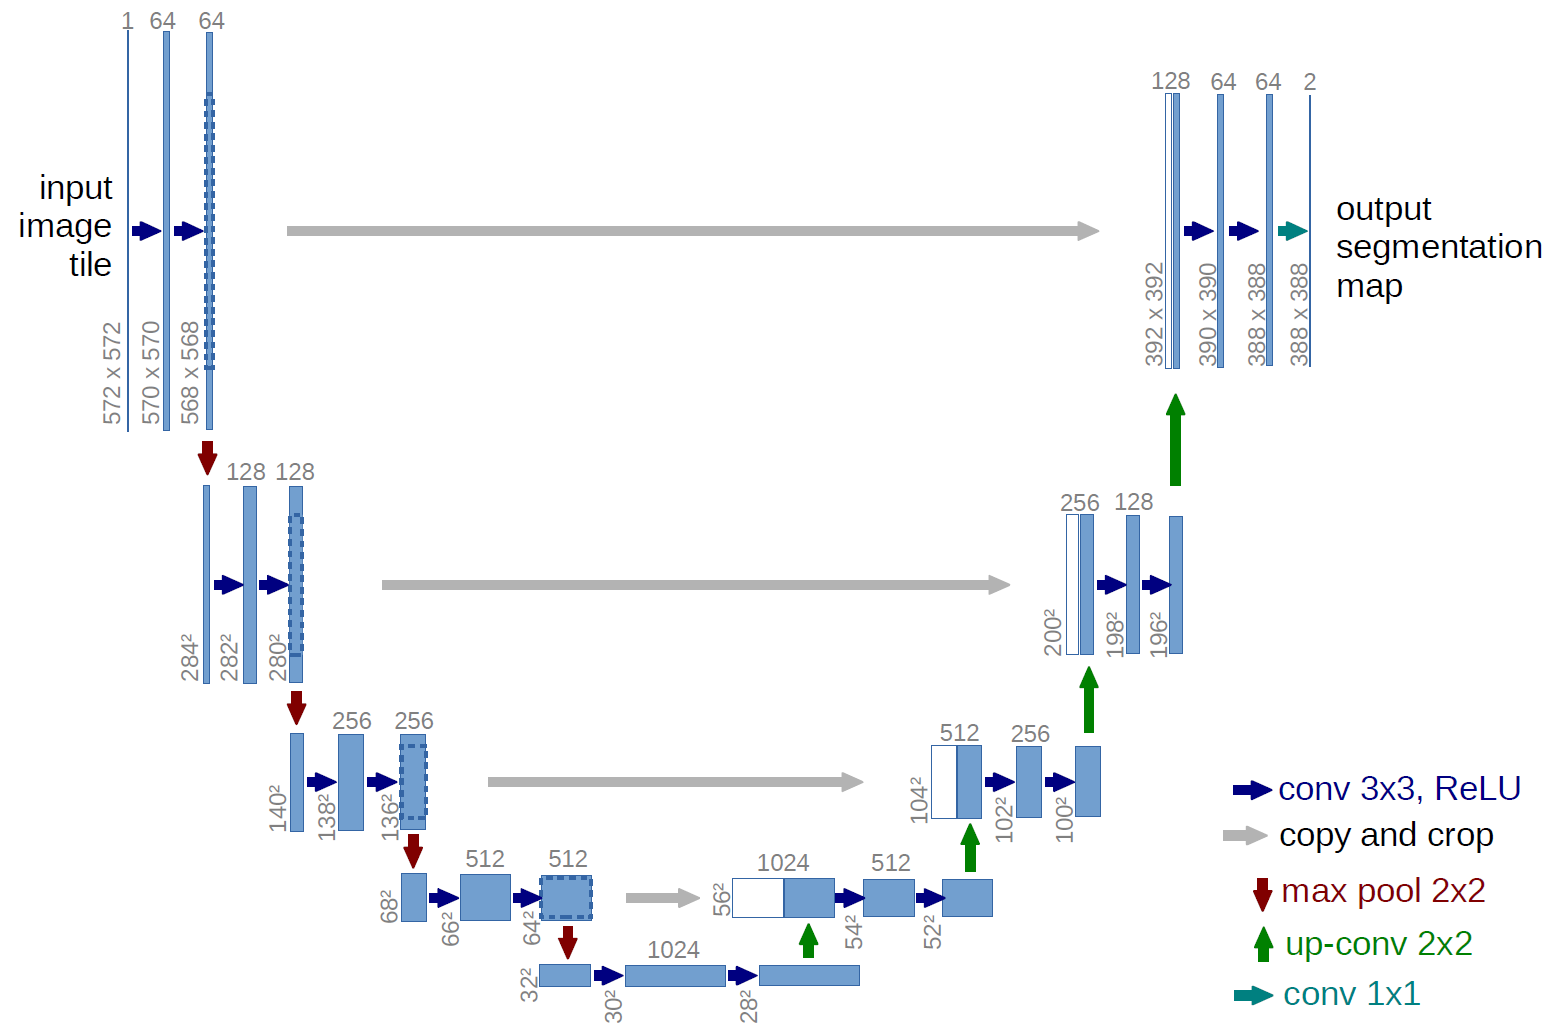

Bus du input channeliai - kur juoda, kur balta 256 x 256 x 2

In [4]:
import torch
import torch.nn as nn
from torch.nn.functional import scaled_mm

device = torch.device('mps')
print(device)

mps


In [5]:
from datasets import load_dataset

ds = load_dataset("ioclab/grayscale_image_aesthetic_10k")

split = ds["train"].train_test_split(test_size=0.2, seed=200)

train_ds = split["train"]
validate_ds = split["test"]

print(train_ds)
print(validate_ds)


Dataset({
    features: ['image', 'grayscale_image', 'caption'],
    num_rows: 8000
})
Dataset({
    features: ['image', 'grayscale_image', 'caption'],
    num_rows: 2000
})


Modelis (pagal schema)

In [11]:
class ColoringModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.steps1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.steps2 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 256x256 -> 128x128
            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.steps3 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.steps4 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.steps5 = nn.Sequential(
            nn.MaxPool2d(2, 2), # 32x32 -> 16x16
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 16x16 -> 32x32
        )

        self.steps6 = nn.Sequential(
            # 128 + 128 (step 4) = 256 kanalai
            nn.Conv2d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 32x32 -> 64x64
        )

        self.steps7 = nn.Sequential(
            # 64 + (step 3) 64 = 128 kanalai
            nn.Conv2d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 64x64 -> 128x128
        )

        self.steps8 = nn.Sequential(
            # 32 + 32 (step 2) = 64 kanalai
            nn.Conv2d(64, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Upsample(scale_factor=2), # 128x128 -> 256x256
        )

        self.steps9 = nn.Sequential(
            # 16 + 16 (step 1) kanalai = 32 kanalai
            nn.Conv2d(32, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, padding='same'),
            nn.Sigmoid()
        )

    def forward(self, x):
        block1 = self.steps1(x)
        block2 = self.steps2(block1)
        block3 = self.steps3(block2)
        block4 = self.steps4(block3)

        block5 = self.steps5(block4)

        # concat
        block6 = self.steps6(torch.cat([block5, block4], dim=1))
        block7 = self.steps7(torch.cat([block6, block3], dim=1))
        block8 = self.steps8(torch.cat([block7, block2], dim=1))
        block9 = self.steps9(torch.cat([block8, block1], dim=1))

        return block9

In [29]:
import numpy as np
def evaluate(model, loader):
    model.eval()
    loss_func = torch.nn.L1Loss() # ta pati loss funkcija kaip ir per traininga
    loss_acum = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images)
            loss = loss_func(pred, labels)
            loss_acum.append(loss.item())

    return np.mean(loss_acum)


In [32]:
from datetime import datetime

def train(model, loader, epoch_count = 10, lr = 1e-3):
    loss_func = torch.nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # zinant kaip blogai modelis pasirode, patikrina, kaip pakeisti svoriu vertes, kad modelis klystu maziau
    # learning rate standartine yra 1e-3 (0.001), is esmes zingsnio dydis keiciant svorius

    model.train()
    start_time = datetime.now()

    for epoch in range(epoch_count):
        loss_acum = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # sumappinami images ir labels
            optimizer.zero_grad() # praeito zingsnio skaiciavimai panaikinami
            pred = model(images) # predictionai
            loss = loss_func(pred, labels) # losses paskaiciavimai
            loss.backward() # paskaiciuojama, kaip kiekvienas svoris prisidejo prie klaidu skaiciaus
            optimizer.step() # optimizuojami svoriai, kad butu sumazintos klaidos
            loss_acum.append(loss.item())
        current_time = datetime.now()
        elapsed = seconds_to_time((current_time - start_time).total_seconds())
        print(f'Epoch: {epoch}, Time: {elapsed}, Loss: {np.mean(loss_acum)}')



def seconds_to_time(seconds):
    s = int(seconds) % 60
    m = int(seconds) // 60
    if m < 1:
        return f'{s}s'
    h = m // 60
    m = m % 60
    if h < 1:
        return f'{m}m{s}s'
    return f'{h}h{m}m{s}s'

In [33]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

class ColorizationDataset(Dataset):
    def __init__(self, hf_ds):
        self.hf_ds = hf_ds
        # Transform for target (RGB)
        self.target_transform = T.Compose([
            T.Resize((256, 256)),
            T.ToTensor()
        ])
        # Transform for input (Grayscale)
        self.input_transform = T.Compose([
            T.Resize((256, 256)),
            T.Grayscale(num_output_channels=1),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.hf_ds)

    def __getitem__(self, idx):
        item = self.hf_ds[idx]
        img = item['image'].convert('RGB')

        target = self.target_transform(img) # 3x256x256
        gray = self.input_transform(img) # 1x256x256

        return gray, target

train_dataset = ColorizationDataset(train_ds)
validate_dataset = ColorizationDataset(validate_ds)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validate_loader = DataLoader(validate_dataset, batch_size=16, shuffle=False)


In [34]:
# Initialize the model and move it to the configured device
model = ColoringModel().to(device)

# Train the model (using a small number of epochs for demonstration)
print("Starting training...")
train(model, train_loader, epoch_count=2, lr=1e-2)

# Evaluate the model
print("Evaluating...")
val_loss = evaluate(model, validate_loader)
print(f"Validation Loss: {val_loss}")


Starting training...
Epoch: 0, Time: 3m29s, Loss: 0.08371385230869055
Epoch: 1, Time: 6m52s, Loss: 0.07291144637018442
Evaluating...
Validation Loss: 0.06816183841228485


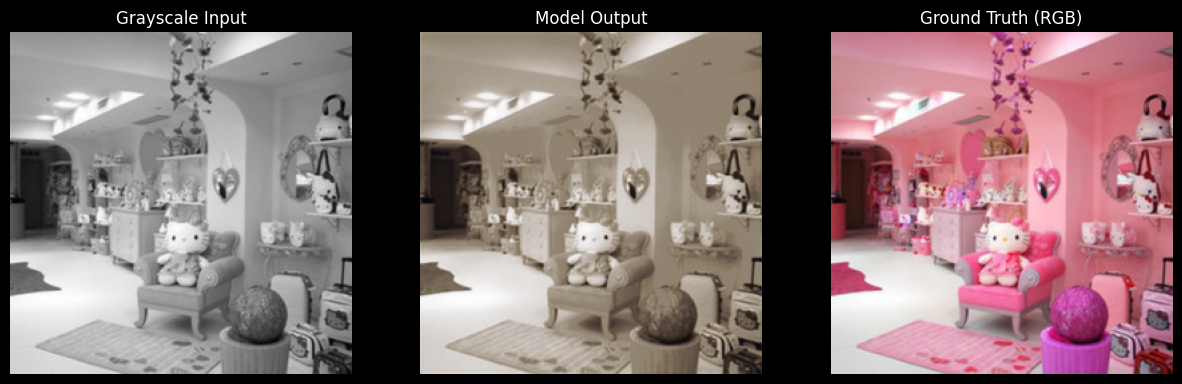

In [43]:
import matplotlib.pyplot as plt

def visualize_result(model, dataset, index=0):
    model.eval()
    inp, target = dataset[index]

    with torch.no_grad():
        # Add batch dimension and move to device: 1x2x256x256
        pred = model(inp.unsqueeze(0).to(device))

    # Prepare input for plotting (take first channel, un-tensorize)
    inp_img = inp[0].cpu().numpy()

    # Prepare target (RGB) for plotting: C x H x W -> H x W x C
    target_img = target.cpu().permute(1, 2, 0).numpy()

    # Prepare prediction (RGB) for plotting
    pred_img = pred.squeeze(0).cpu().permute(1, 2, 0).numpy()
    pred_img = np.clip(pred_img, 0, 1) # Ensure values are 0-1 for matplotlib imshow

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(inp_img, cmap='gray')
    axes[0].set_title('Grayscale Input')
    axes[0].axis('off')

    axes[1].imshow(pred_img)
    axes[1].set_title('Model Output')
    axes[1].axis('off')

    axes[2].imshow(target_img)
    axes[2].set_title('Ground Truth (RGB)')
    axes[2].axis('off')

    plt.show()

# Show a photo with before and after
visualize_result(model, validate_dataset, index=860)


In [18]:
torch.save(model.state_dict(), "model_color.pth")